<a href="https://colab.research.google.com/github/liujh22/learngit/blob/master/Group_B_working_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="在 Colab 中打开"/></a>

In [1]:
# @title 导入软件包
from pathlib import Path
import json
import requests
import os
import numpy as np
import matplotlib.pyplot as plt

### **步骤 1：导入必要的软件包**

本单元导入数据处理、文件操作、网络请求、数值计算和绘图所需的 Python 库。其中，`pathlib` 用于处理文件路径，`json` 和 `requests` 用于处理网络数据，`os` 用于与操作系统交互，`numpy` 用于数值运算，`matplotlib.pyplot` 用于绘图。

In [2]:
# @title 数据加载与导入

# 设置数据路径
root = r'/content'
Path(root).mkdir(exist_ok=True)
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

# 本项目所需文件： 'VR2_2021_03_20_1_PCAed_spk.npy'; 'VR2_2021_03_20_1_SVD_dec.npy'; 'VR2_2021_03_20_trans.npz'; 'VR2_2021_04_06_1_SVD_dec.npy'; 'VR2_2021_04_06_trans.npz';
# 文件列表（续）：'TX105_2022_10_08_2_SVD_dec.npy'; 'TX105_2022_10_08_trans.npz'; 'TX105_2022_10_19_2_SVD_dec.npy'; 'TX105_2022_10_19_trans.npz'
# 文件列表（续）：'Beh_sup_train1_before_learning.npy'; 'Beh_sup_train1_after_learning.npy'; 'Beh_unsup_train1_before_learning.npy'; 'Beh_unsup_train1_after_learning.npy'
sup_bef = 'VR2_2021_03_20_1' # 监督学习前的示例小鼠会话
sup_aft = 'VR2_2021_04_06_1' # 监督学习后的示例小鼠会话
unsup_bef = 'TX105_2022_10_08_2' # 无监督学习前的示例小鼠会话
unsup_aft = 'TX105_2022_10_19_2' # 无监督学习后的示例小鼠会话

# 从 Figshare 下载文件
file_ID = [54866153, 54866354, 54184211, 54866333, 54184214, 54866237, 54184028, 54866150, 54184031, 54183863, 54183860, 54183914, 54183917] # 文件 ID

BASE_URL = 'https://api.figshare.com/v2'
r = requests.get(BASE_URL + '/articles/' + str(28811129)) # 28811129 是整个数据集的 ID
file_metadata = json.loads(r.text)
for file in file_metadata['files']:
  if file['id'] in file_ID: # 仅下载 file_ID 中列出的文件
    fn = os.path.join(root, file['name'])
    if not os.path.isfile(fn):
      response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
      open(fn, 'wb').write(response.content)
    print(fn)

OSError: [Errno 30] Read-only file system: '/content'

### **步骤 2：加载数据并从 Figshare 下载文件**

本单元创建数据目录并从 Figshare 下载实验文件。代码先定义小鼠实验会话 ID（如 `sup_bef`、`unsup_aft`），再遍历文件 ID 列表；只有本地不存在对应文件时才会下载，以确保分析所需的数据齐全。

In [ ]:
# @title 加载无监督学习后的原始数据
PCAed_data_aft = np.load(os.path.join(root, unsup_aft + '_SVD_dec.npy'), allow_pickle = True).item()

U_aft = PCAed_data_aft['U'] #（SVD 成分 × 神经元 ID）
V_aft = PCAed_data_aft['V'] #（SVD 成分 × 帧）

V_a = V_aft
n_components = V_a.shape[0]
nfrs_aft = V_a.shape[1]
print("Available data:", list(PCAed_data_aft.keys()))
print(f"U shape (components x [something idk]): {U_aft.shape}")
print(f"V shape (components × frames): {V_aft.shape}")
print(f"Number of components: {n_components}")
print(f"Number of [something idk] represented in U: {U_aft.shape[1]}")
print(f"Number of frames: {nfrs_aft}")

Available data: ['U', 'V', 'SVD_model']
U shape (components x [something idk]): (400, 55653)
V shape (components × frames): (400, 15553)
Number of components: 400
Number of [something idk] represented in U: 55653
Number of frames: 15553


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# @title 加载无监督学习前的原始数据
PCAed_data_bef = np.load(os.path.join(root, unsup_bef + '_SVD_dec.npy'), allow_pickle = True).item()

U_bef = PCAed_data_bef['U'] #（SVD 成分 × 神经元 ID）
V_bef = PCAed_data_bef['V'] #（SVD 成分 × 帧）

V_b = V_bef
n_components = V_b.shape[0]
nfrs_bef = V_b.shape[1]
print("Available data:", list(PCAed_data_bef.keys()))
print(f"U shape (components x [something idk]): {U_bef.shape}")
print(f"V shape (components × frames): {V_bef.shape}")
print(f"Number of components: {n_components}")
print(f"Number of [something idk] represented in U: {U_bef.shape[1]}")
print(f"Number of frames: {nfrs_bef}")

Available data: ['U', 'V', 'SVD_model']
U shape (components x [something idk]): (400, 58941)
V shape (components × frames): (400, 27740)
Number of components: 400
Number of [something idk] represented in U: 58941
Number of frames: 27740


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
print(PCAed_data_bef.keys())

dict_keys(['U', 'V', 'SVD_model'])


### **步骤 3：加载原始神经数据**

本单元从 `.npy` 文件加载经过主成分分析（PCA）转换的神经数据，包括 `U_sp`（SVD 成分 × 神经元 ID）和 `V_tm`（SVD 成分 × 帧）。这两个矩阵来自对神经活动进行的奇异值分解（SVD）。随后打印矩阵形状、成分数和帧数，以了解数据维度。

In [ ]:
print(U_bef)
print(U_bef.shape)

[[ 0.00272246  0.00513969  0.00305193 ...  0.00443468  0.00626681
   0.00753923]
 [ 0.00158561  0.00944445  0.01077767 ... -0.00320483 -0.00175674
  -0.00557396]
 [ 0.00658055  0.00543068 -0.00791137 ... -0.00404008 -0.00421362
  -0.00432667]
 ...
 [-0.00532768  0.00525565 -0.00029503 ... -0.00495168 -0.00266797
   0.0041697 ]
 [ 0.01552347 -0.00345775  0.00416834 ... -0.00189773  0.00225027
  -0.0077083 ]
 [ 0.00081072  0.00368246 -0.00421563 ...  0.00710385  0.0060885
  -0.00266191]]
(400, 58941)


### **步骤 4：查看 `U_sp`**

本单元打印 `U_sp` 矩阵的内容和形状。`U_sp` 表示空间成分，即每个神经元对各个 SVD 成分的贡献。

In [ ]:
print(V_bef)
print(V_bef.shape)

[[-77.5342      28.131079    36.156796   ... -25.48387    -31.824104
   20.021708  ]
 [-13.517485    16.861177    14.611678   ...  -1.6790253   -4.0599074
    6.120057  ]
 [  4.3240533    6.88708     10.507226   ...  -0.30501238   2.4599636
   -0.52198315]
 ...
 [ -0.12896973   1.4166374    1.8564667  ...   1.8062942    0.73277414
    5.1364493 ]
 [ -0.48515224   0.88802695  -0.16914415 ...   1.4709154   -0.5677221
   -1.0459708 ]
 [ -0.27993786   1.6377776    2.1216116  ...  -2.600178    -0.6727436
    0.42677665]]
(400, 27740)


### **步骤 5：查看 `V_tm`**

本单元打印 `V_tm` 矩阵的内容和形状。`V_tm` 表示时间成分，即各个 SVD 成分随记录帧的变化。

In [ ]:
# @title 加载无监督学习后的行为数据

beh_aft = np.load(os.path.join(root, 'Beh_unsup_train1_after_learning.npy'), allow_pickle=1).item()[unsup_aft]
print(beh_aft.keys())

stim_id_aft = beh_aft['stim_id'] # 编码含义：0：circle1，1：circle2，2：leaf1，3：leaf2，4：leaf3
ntrials_aft, uniqW_aft, WallN_aft = beh_aft['ntrials'], beh_aft['UniqWalls'], beh_aft['WallName']
SoundPos_aft = beh_aft['SoundPos']

lick_fr_aft = beh_aft['LickFr'] # 发生舔舐的帧
cue_fr_aft = beh_aft['SoundFr'] # 出现提示音的帧
stim_fr_aft = beh_aft['ft_WallID'] # 每一帧对应的试次刺激
pos_fr_aft = beh_aft['ft_Pos'] # 每一帧在走廊内的位置
cum_pos_fr_aft = beh_aft['ft_PosCum']
VR_move_aft = beh_aft['ft_move']>0 # 虚拟场景正在移动的帧

name_stim1 = uniqW_aft[stim_id_aft==2][0] # 刺激 1 的名称；监督实验中的奖励刺激（leaf1）
name_stim2 = uniqW_aft[stim_id_aft==0][0] # 刺激 2 的名称；监督实验中的非奖励刺激（circle1）
stim1_tr = WallN_aft==name_stim1
stim2_tr = WallN_aft==name_stim2

# 获取刺激区域内各帧的索引（0–40 为纹理区域，40–60 为灰色区域）
stim1_idx = (stim_fr_aft==name_stim1) & (pos_fr_aft<40)
stim2_idx = (stim_fr_aft==name_stim2) & (pos_fr_aft<40)
gray_idx = ((stim_fr_aft==name_stim1) | (stim_fr_aft==name_stim2)) & (pos_fr_aft>=40)

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])


In [ ]:
# @title 加载无监督学习前的行为数据

beh_bef = np.load(os.path.join(root, 'Beh_unsup_train1_before_learning.npy'), allow_pickle=1).item()[unsup_bef]
print(beh_bef.keys())

stim_id_bef = beh_bef['stim_id'] # 编码含义：0：circle1，1：circle2，2：leaf1，3：leaf2，4：leaf3
ntrials_bef, uniqW_bef, WallN_bef = beh_bef['ntrials'], beh_bef['UniqWalls'], beh_bef['WallName']
SoundPos_bef = beh_bef['SoundPos']

lick_fr_bef = beh_bef['LickFr'] # 发生舔舐的帧
cue_fr_bef = beh_bef['SoundFr'] # 出现提示音的帧
stim_fr_bef = beh_bef['ft_WallID'] # 每一帧对应的试次刺激
pos_fr_bef = beh_bef['ft_Pos'] # 每一帧在走廊内的位置
cum_pos_fr_bef = beh_bef['ft_PosCum']
VR_move_bef = beh_bef['ft_move']>0 # 虚拟场景正在移动的帧

name_stim1_bef = uniqW_bef[stim_id_bef==2][0] # 刺激 1 的名称；监督实验中的奖励刺激（leaf1）
name_stim2_bef = uniqW_bef[stim_id_bef==0][0] # 刺激 2 的名称；监督实验中的非奖励刺激（circle1）
stim1_tr_bef = WallN_bef==name_stim1
stim2_tr_bef = WallN_bef==name_stim2

# 获取刺激区域内各帧的索引（0–40 为纹理区域，40–60 为灰色区域）
stim1_idx_bef = (stim_fr_bef==name_stim1) & (pos_fr_bef<40)
stim2_idx_bef = (stim_fr_bef==name_stim2) & (pos_fr_bef<40)
gray_idx_bef = ((stim_fr_bef==name_stim1) | (stim_fr_bef==name_stim2)) & (pos_fr_bef>=40)

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])


### **步骤 6：加载行为数据**

本单元从 `.npy` 文件加载 `unsup_aft` 小鼠会话的行为数据，并提取刺激 ID、试次信息、声音位置、舔舐帧、提示音帧、刺激帧、走廊内位置和运动状态等指标。代码还识别 `leaf1` 和 `circle1` 等刺激，并为刺激区域和灰色区域建立索引。

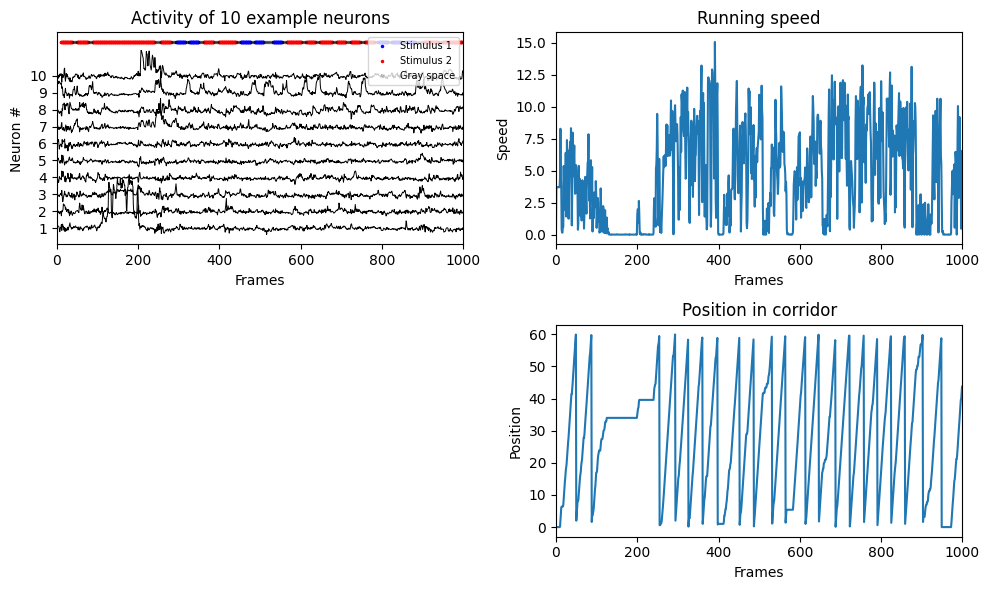

In [ ]:
# @title 显示无监督学习后的示例神经活动
nneu = 10
nfr = 1000

example_activity_aft = U_aft[:, :nneu].T @ V_aft
seg_aft = example_activity_aft[:, :nfr]

trace_spacing_aft = 4 * seg_aft.std()
offset_aft = np.arange(nneu) * trace_spacing_aft

fig_aft = plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(seg_aft.T + offset_aft, 'k-', linewidth = 0.7)

stim1_plot_idx = np.where(stim1_idx[:nfr])[0]
stim2_plot_idx = np.where(stim2_idx[:nfr])[0]
gray_plot_idx = np.where(gray_idx[:nfr])[0]

# 在神经活动轨迹上方标记刺激
marker_height_aft = offset_aft[-1] + 2 * trace_spacing_aft

plt.plot(
    stim1_plot_idx,
    np.full(len(stim1_plot_idx), marker_height_aft),
    'b.',
    markersize=3,
    label='Stimulus 1'
)

plt.plot(
    stim2_plot_idx,
    np.full(len(stim2_plot_idx), marker_height_aft),
    'r.',
    markersize=3,
    label='Stimulus 2'
)
plt.plot(
    gray_plot_idx,
    np.full(len(gray_plot_idx), marker_height_aft),
    'k.',
    alpha=0.1,
    markersize=3,
    label='Gray space'
)

plt.yticks(offset_aft, np.arange(1, nneu + 1))
plt.xlim(0, nfr)
plt.ylabel('Neuron #')
plt.xlabel('Frames')
plt.title('Activity of 10 example neurons')
plt.legend(fontsize=7, loc='upper right')

# 跑步速度
plt.subplot(2, 2, 2)
plt.plot(beh_aft['RunFr'][:nfr])
plt.xlim(0, nfr)
plt.ylabel('Speed')
plt.xlabel('Frames')
plt.title('Running speed')

plt.subplot(2, 2, 4)
plt.plot(pos_fr_aft[:nfr])
plt.xlim(0, nfr)
plt.ylabel('Position')
plt.xlabel('Frames')
plt.title('Position in corridor')

plt.tight_layout()
plt.show()

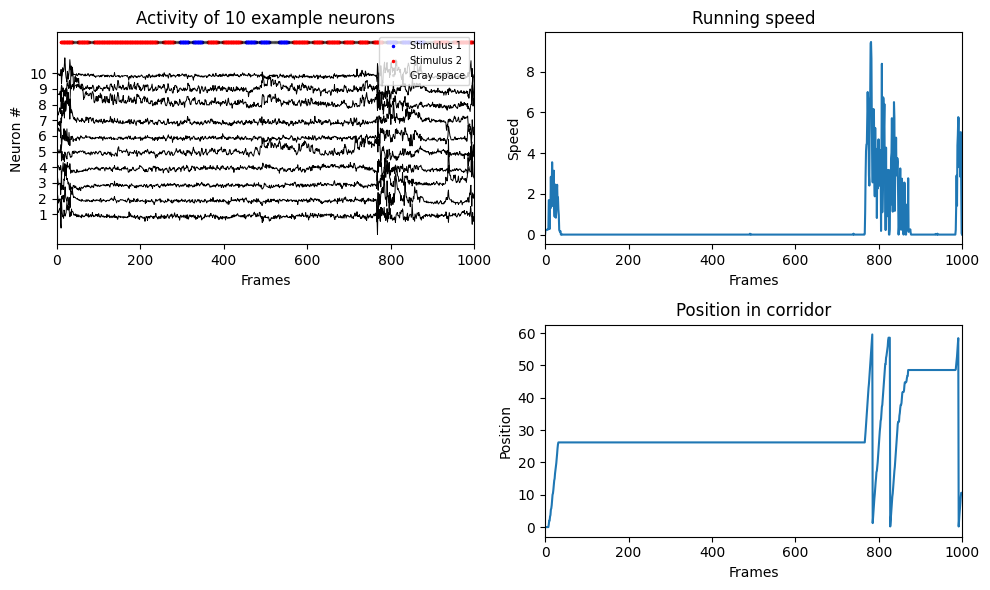

In [ ]:
# @title 显示无监督学习前的示例神经活动
nneu = 10
nfr = 1000

example_activity_bef = U_bef[:, :nneu].T @ V_bef
seg_bef = example_activity_bef[:, :nfr]

trace_spacing_bef = 4 * seg_bef.std()
offset_bef = np.arange(nneu) * trace_spacing_bef

fig_bef = plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.plot(seg_bef.T + offset_bef, 'k-', linewidth = 0.7)

stim1_plot_idx_bef = np.where(stim1_idx_bef[:nfr])[0]
stim2_plot_idx_bef = np.where(stim2_idx_bef[:nfr])[0]
gray_plot_idx_bef = np.where(gray_idx_bef[:nfr])[0]

# 在神经活动轨迹上方标记刺激
marker_height_bef = offset_bef[-1] + 2 * trace_spacing_bef

plt.plot(
    stim1_plot_idx,
    np.full(len(stim1_plot_idx), marker_height_bef),
    'b.',
    markersize=3,
    label='Stimulus 1'
)

plt.plot(
    stim2_plot_idx,
    np.full(len(stim2_plot_idx), marker_height_bef),
    'r.',
    markersize=3,
    label='Stimulus 2'
)
plt.plot(
    gray_plot_idx,
    np.full(len(gray_plot_idx), marker_height_bef),
    'k.',
    alpha=0.1,
    markersize=3,
    label='Gray space'
)

plt.yticks(offset_bef, np.arange(1, nneu + 1))
plt.xlim(0, nfr)
plt.ylabel('Neuron #')
plt.xlabel('Frames')
plt.title('Activity of 10 example neurons')
plt.legend(fontsize=7, loc='upper right')

# 跑步速度
plt.subplot(2, 2, 2)
plt.plot(beh_bef['RunFr'][:nfr])
plt.xlim(0, nfr)
plt.ylabel('Speed')
plt.xlabel('Frames')
plt.title('Running speed')

plt.subplot(2, 2, 4)
plt.plot(pos_fr_bef[:nfr])
plt.xlim(0, nfr)
plt.ylabel('Position')
plt.xlabel('Frames')
plt.title('Position in corridor')

plt.tight_layout()
plt.show()

### **步骤 7：可视化示例神经活动和行为**

本单元重建少量神经元的一段活动并绘制其轨迹，同时标出不同刺激及灰色区域出现的时间。此外还绘制同一时间范围内小鼠的跑步速度和走廊位置，便于直观比较神经活动与行为。

In [ ]:
print(example_activity_aft.shape)
print(example_activity_bef.shape)

(10, 15553)
(10, 27740)


### **步骤 8：查看示例活动的形状**

本单元打印上一步计算得到的 `example_activity` 数组形状，用于确认示例神经活动的维度。

In [ ]:
# @title 将基于帧的活动转换为“信号 × 试次 × 位置”（无监督学习后）

from scipy import interpolate

def activity_by_trial_and_position_aft(
    activity_by_frame_aft,
    cumulative_position_aft,
    n_trials_aft,
    corridor_length=60
):
    """
    将按记录帧索引的活动转换为按试次和走廊位置索引的活动。

    参数
    ----
    activity_by_frame : 数组
        形状：信号 × 帧。
        信号可以是重建的神经元活动或 SVD 成分。

    cumulative_position : 数组
        每个记录帧对应的走廊累计位置。

    n_trials : 整数
        走廊试次数。

    corridor_length : 整数
        每个试次的位置分箱数，默认值为 60。

    返回值
    ------
    activity_trial_pos : 数组
        形状：信号 × 试次 × 位置。
    """

    n_frames_aft = activity_by_frame_aft.shape[1]
    max_cum_pos_aft = n_trials_aft * corridor_length
    target_positions_aft = np.arange(max_cum_pos_aft)

    # 神经数据和行为数据必须对应相同的记录帧
    if len(cumulative_position_aft) < n_frames_aft:
        raise ValueError(
            "The behavioral position array has fewer frames than the "
            "neural activity array."
        )

    source_positions_aft = cumulative_position_aft[:n_frames_aft]

    # 移除重复的累计位置值，因为小鼠停顿时这些值
    # 可能导致插值问题。
    unique_positions_aft, unique_indices_aft = np.unique(
        source_positions_aft,
        return_index=True
    )

    interpolated_activity_aft = np.empty(
        (activity_by_frame_aft.shape[0], max_cum_pos_aft),
        dtype=np.float32
    )

    for signal_idx_aft in range(activity_by_frame_aft.shape[0]):
        signal_aft = activity_by_frame_aft[signal_idx_aft, unique_indices_aft]

        interpolation_model_aft = interpolate.interp1d(
            unique_positions_aft,
            signal_aft,
            bounds_error=False,
            fill_value="extrapolate"
        )

        interpolated_activity_aft[signal_idx_aft] = interpolation_model_aft(
            target_positions_aft
        )

    activity_trial_pos_aft = interpolated_activity_aft.reshape(
        activity_by_frame_aft.shape[0],
        n_trials_aft,
        corridor_length
    )

    return activity_trial_pos_aft

In [ ]:
# @title 将基于帧的活动转换为“信号 × 试次 × 位置”（无监督学习前）

from scipy import interpolate

def activity_by_trial_and_position_bef(
    activity_by_frame_bef,
    cumulative_position_bef,
    n_trials_bef,
    corridor_length=60
):
    """
    将按记录帧索引的活动转换为按试次和走廊位置索引的活动。

    参数
    ----
    activity_by_frame : 数组
        形状：信号 × 帧。
        信号可以是重建的神经元活动或 SVD 成分。

    cumulative_position : 数组
        每个记录帧对应的走廊累计位置。

    n_trials : 整数
        走廊试次数。

    corridor_length : 整数
        每个试次的位置分箱数，默认值为 60。

    返回值
    ------
    activity_trial_pos : 数组
        形状：信号 × 试次 × 位置。
    """

    n_frames_bef = activity_by_frame_bef.shape[1]
    max_cum_pos_bef = n_trials_bef * corridor_length
    target_positions_bef = np.arange(max_cum_pos_bef)

    # 神经数据和行为数据必须对应相同的记录帧
    if len(cumulative_position_bef) < n_frames_bef:
        raise ValueError(
            "The behavioral position array has fewer frames than the "
            "neural activity array."
        )

    source_positions_bef = cumulative_position_bef[:n_frames_bef]

    # 移除重复的累计位置值，因为小鼠停顿时这些值
    # 可能导致插值问题。
    unique_positions_bef, unique_indices_bef = np.unique(
        source_positions_bef,
        return_index=True
    )

    interpolated_activity_bef = np.empty(
        (activity_by_frame_bef.shape[0], max_cum_pos_bef),
        dtype=np.float32
    )

    for signal_idx_bef in range(activity_by_frame_bef.shape[0]):
        signal_bef = activity_by_frame_bef[signal_idx_bef, unique_indices_bef]

        interpolation_model_bef = interpolate.interp1d(
            unique_positions_bef,
            signal_bef,
            bounds_error=False,
            fill_value="extrapolate"
        )

        interpolated_activity_bef[signal_idx_bef] = interpolation_model_bef(
            target_positions_bef
        )

    activity_trial_pos_bef = interpolated_activity_bef.reshape(
        activity_by_frame_bef.shape[0],
        n_trials_bef,
        corridor_length
    )

    return activity_trial_pos_bef

### **步骤 9：定义按试次和位置转换帧活动的函数**

本单元定义 `activity_by_trial_and_position` 函数，将按记录帧索引的神经活动或 SVD 成分活动转换为按试次和走廊位置索引的数据。函数通过插值处理小鼠停顿时累计位置重复的情况，并将数据重塑为“信号 × 试次 × 位置”的格式。

In [ ]:
component_activity_trial_pos_aft = activity_by_trial_and_position_aft(
    activity_by_frame_aft = V_aft,
    cumulative_position_aft = cum_pos_fr_aft,
    n_trials_aft = ntrials_aft,
    corridor_length=60
)
print("Component activity shape(after learning):",component_activity_trial_pos_aft.shape)

component_activity_trial_pos_bef = activity_by_trial_and_position_bef(
    activity_by_frame_bef = V_bef,
    cumulative_position_bef = cum_pos_fr_bef,
    n_trials_bef = ntrials_bef,
    corridor_length=60
)
print("Component activity shape(before learning):",component_activity_trial_pos_bef.shape)

Component activity shape(after learning): (400, 259, 60)
Component activity shape(before learning): (400, 201, 60)


### **步骤 10：将转换应用于 SVD 成分**

本单元调用前一步定义的函数，把按帧组织的 SVD 成分 `V_tm` 转换为按试次和位置组织的活动。结果 `component_activity_trial_pos` 的维度为 `(n_components, n_trials, corridor_length)`，可用于后续结合试次和空间位置的分析。

In [ ]:
# @title 移除灰色区域
pattern_activity_aft = component_activity_trial_pos_aft[:, :, :40]

print("Patterned tunnel only shape (after learning):", pattern_activity_aft.shape)
pattern_activity_bef = component_activity_trial_pos_bef[:, :, :40]

print("Patterned tunnel only shape (before learning):", pattern_activity_bef.shape)

Patterned tunnel only shape (after learning): (400, 259, 40)
Patterned tunnel only shape (before learning): (400, 201, 40)


### **步骤 11：从活动数据中移除灰色区域**

本单元仅保留走廊中“图案隧道”对应的活动，从而排除灰色区域。代码截取 `component_activity_trial_pos` 的前 40 个位置（假设位置 0–39 为图案隧道），并将结果保存到 `pattern_activity`。

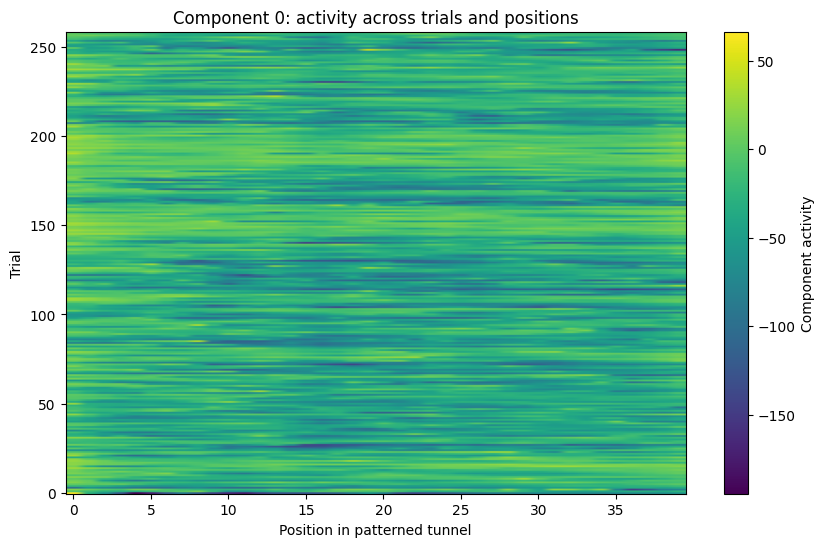

In [ ]:
# @title 可视化学习后一个成分在不同试次和位置上的活动

component_number = 0

plt.figure(figsize=(10, 6))

plt.imshow(
    pattern_activity_aft[component_number, :, :],
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Component activity')
plt.xlabel('Position in patterned tunnel')
plt.ylabel('Trial')
plt.title(f'Component {component_number}: activity across trials and positions')

plt.show()


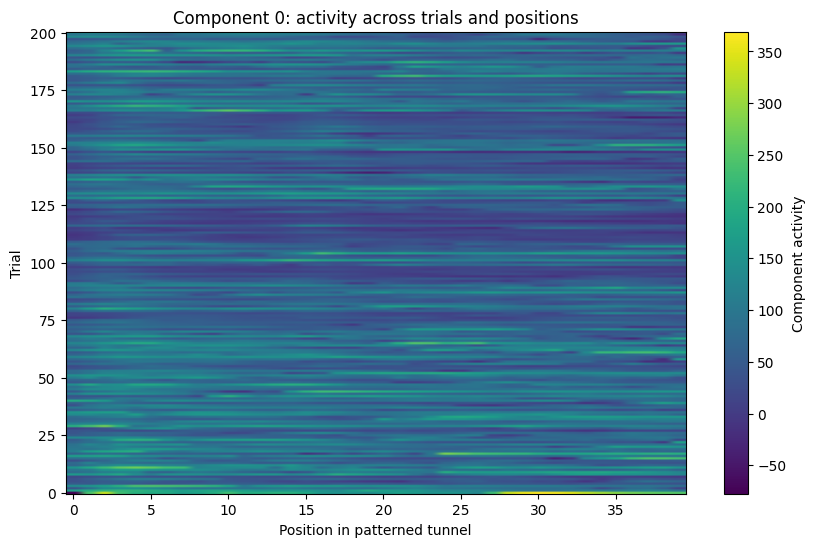

In [ ]:
# @title 可视化学习前一个成分在不同试次和位置上的活动

component_number = 0

plt.figure(figsize=(10, 6))

plt.imshow(
    pattern_activity_bef[component_number, :, :],
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Component activity')
plt.xlabel('Position in patterned tunnel')
plt.ylabel('Trial')
plt.title(f'Component {component_number}: activity across trials and positions')

plt.show()


### **步骤 12：可视化一个成分在不同试次和位置上的活动**

本单元使用 `imshow` 显示单个 SVD 成分在所有试次及图案隧道各位置上的活动。横轴表示隧道位置，纵轴表示试次编号，颜色强度表示成分活动大小。

Slice shape: (5, 5)


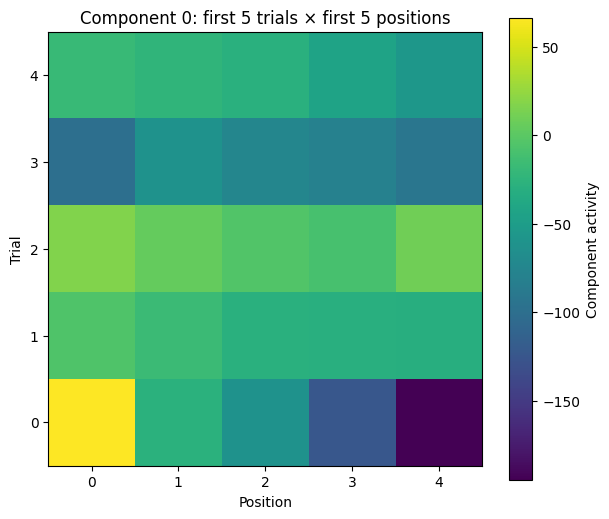

In [ ]:
# @title 一个成分在学习后前 5 个试次和前 5 个位置的活动

component_number = 0

small_slice = pattern_activity_aft[
    component_number,
    :5,
    :5
]

print("Slice shape:", small_slice.shape)

plt.figure(figsize=(7, 6))

plt.imshow(
    small_slice,
    aspect='equal',
    origin='lower'
)

plt.colorbar(label='Component activity')
plt.xlabel('Position')
plt.ylabel('Trial')
plt.xticks(range(5), range(5))
plt.yticks(range(5), range(5))
plt.title(f'Component {component_number}: first 5 trials × first 5 positions')

plt.show()

Slice shape: (5, 5)


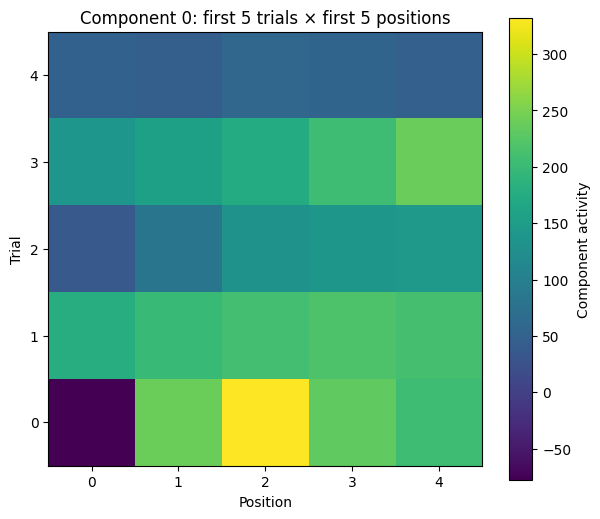

In [ ]:
# @title 一个成分在学习前前 5 个试次和前 5 个位置的活动

component_number = 0

small_slice = pattern_activity_bef[
    component_number,
    :5,
    :5
]

print("Slice shape:", small_slice.shape)

plt.figure(figsize=(7, 6))

plt.imshow(
    small_slice,
    aspect='equal',
    origin='lower'
)

plt.colorbar(label='Component activity')
plt.xlabel('Position')
plt.ylabel('Trial')
plt.xticks(range(5), range(5))
plt.yticks(range(5), range(5))
plt.title(f'Component {component_number}: first 5 trials × first 5 positions')

plt.show()

### **步骤 13：可视化成分活动的局部数据**

本单元只显示单个 SVD 成分在前 5 个试次和前 5 个位置上的数据。这个放大视图便于更细致地检查转换后的数据结构和数值。

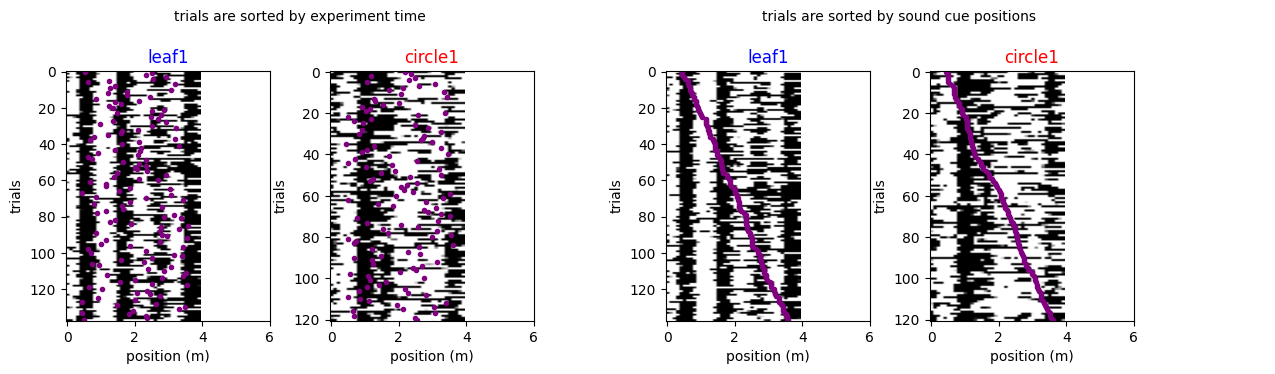

In [ ]:
# @title 按试次和位置绘制活动（学习后的示例神经元）
def im_plot_aft(ax, spk_in, cue_pos, sort_cue=0):
    sort_ind = np.argsort(cue_pos) if sort_cue else np.arange(len(cue_pos)).astype(int)
    ax.imshow(spk_in[sort_ind], cmap='gray_r', vmin=0, vmax=0.5)
    ax.plot(cue_pos[sort_ind], np.arange(len(cue_pos)), marker='.',color='purple', ls='None')
    ax.set_aspect('auto')
    ax.set_ylabel('trials')
    ax.set_xlabel('position (m)')
    ax.set_xticks([0, 20, 40, 60], [0, 2, 4 ,6])

n = 30 # 示例神经元 ID（可尝试其他神经元）

fig_aft = plt.figure(figsize=(12, 2.5))
axes_aft = [fig_aft.add_axes([0, 0, 0.17, 1]), fig_aft.add_axes([0.22, 0, 0.17, 1]), fig_aft.add_axes([0.5, 0, 0.17, 1]), fig_aft.add_axes([0.72, 0, 0.17, 1])]

# 按实验时间对试次排序
im_plot_aft(axes_aft[0], pattern_activity_aft[n, stim1_tr], SoundPos_aft[stim1_tr], sort_cue=0)
axes_aft[0].set_title('leaf1', color='b')

im_plot_aft(axes_aft[1], pattern_activity_aft[n, stim2_tr], SoundPos_aft[stim2_tr], sort_cue=0)
axes_aft[1].set_title('circle1', color='r')

# 按声音提示位置对试次排序
im_plot_aft(axes_aft[2], pattern_activity_aft[n, stim1_tr], SoundPos_aft[stim1_tr], sort_cue=1)
axes_aft[2].set_title('leaf1', color='b')

im_plot_aft(axes_aft[3], pattern_activity_aft[n, stim2_tr], SoundPos_aft[stim2_tr], sort_cue=1)
axes_aft[3].set_title('circle1', color='r')

text_ax_aft = fig_aft.add_axes([0, 0, 1, 1])
text_ax_aft.axis('off')
text_ax_aft.text(0.09, 1.2, 'trials are sorted by experiment time')
text_ax_aft.text(0.58, 1.2, 'trials are sorted by sound cue positions')
plt.show()

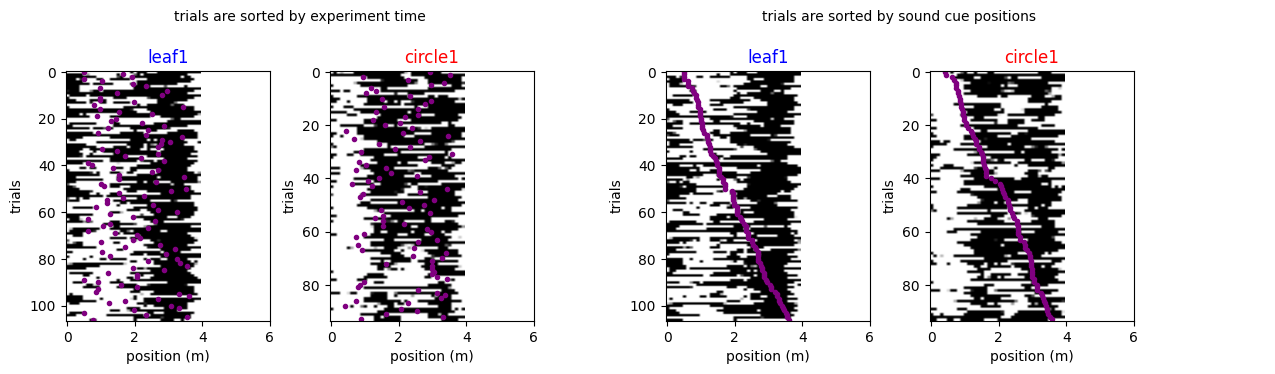

In [ ]:
# @title 按试次和位置绘制活动（学习前的示例神经元）
def im_plot_bef(ax, spk_in, cue_pos, sort_cue=0):
    sort_ind = np.argsort(cue_pos) if sort_cue else np.arange(len(cue_pos)).astype(int)
    ax.imshow(spk_in[sort_ind], cmap='gray_r', vmin=0, vmax=0.5)
    ax.plot(cue_pos[sort_ind], np.arange(len(cue_pos)), marker='.',color='purple', ls='None')
    ax.set_aspect('auto')
    ax.set_ylabel('trials')
    ax.set_xlabel('position (m)')
    ax.set_xticks([0, 20, 40, 60], [0, 2, 4 ,6])

n = 30 # 示例神经元 ID（可尝试其他神经元）

fig_bef = plt.figure(figsize=(12, 2.5))
axes_bef = [fig_bef.add_axes([0, 0, 0.17, 1]), fig_bef.add_axes([0.22, 0, 0.17, 1]), fig_bef.add_axes([0.5, 0, 0.17, 1]), fig_bef.add_axes([0.72, 0, 0.17, 1])]

# 按实验时间对试次排序
im_plot_bef(axes_bef[0], pattern_activity_bef[n, stim1_tr_bef], SoundPos_bef[stim1_tr_bef], sort_cue=0)
axes_bef[0].set_title('leaf1', color='b')

im_plot_bef(axes_bef[1], pattern_activity_bef[n, stim2_tr_bef], SoundPos_bef[stim2_tr_bef], sort_cue=0)
axes_bef[1].set_title('circle1', color='r')

# 按声音提示位置对试次排序
im_plot_bef(axes_bef[2], pattern_activity_bef[n, stim1_tr_bef], SoundPos_bef[stim1_tr_bef], sort_cue=1)
axes_bef[2].set_title('leaf1', color='b')

im_plot_bef(axes_bef[3], pattern_activity_bef[n, stim2_tr_bef], SoundPos_bef[stim2_tr_bef], sort_cue=1)
axes_bef[3].set_title('circle1', color='r')

text_ax_bef = fig_bef.add_axes([0, 0, 1, 1])
text_ax_bef.axis('off')
text_ax_bef.text(0.09, 1.2, 'trials are sorted by experiment time')
text_ax_bef.text(0.58, 1.2, 'trials are sorted by sound cue positions')
plt.show()

### **步骤 14：按试次和位置绘制示例神经元活动**

本单元定义辅助函数 `im_plot`，并用它绘制一个示例神经元在不同试次和位置上的活动。四个子图分别展示按实验时间排序以及按声音提示位置排序的 `leaf1` 和 `circle1` 活动，有助于观察空间调谐以及神经反应与刺激和行为事件的关系。

### **步骤 15：定义跨会话脑区 decoder**

这个工具单元把两个会话表示为相同的特征空间：对每个脑区先通过 SVD 的 U 权重重建脑区平均活动，再以该会话灰墙位置（40–59）的均值和标准差进行无标签标准化，最后保留纹理位置 0–39，得到每个试次固定的 40 维特征。

解码器为 StandardScaler 加带类别平衡的逻辑回归。两个迁移方向分别使用独立模型，每个模型只在自己的源会话上拟合；bootstrap 固定随机种子 2，标签置换检验固定随机种子 1，模型与交叉验证固定随机种子 0，保证结果可复现。

In [ ]:
# CROSS_SESSION_AREA_DECODER_UTILS：跨会话脑区解码工具
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

AREA_CODES = {
    "V1": (8,),
    "medial": (0, 1, 2, 9),
    "lateral": (5, 6),
    "anterior": (3, 4),
}
ANALYSIS_AREAS = ("V1", "medial", "lateral", "anterior", "visual_all")


def make_area_masks(iarea):
    """根据原始脑区编码生成四个视觉脑区及其合并区域的掩码。"""
    iarea = np.asarray(iarea).ravel()
    masks = {name: np.isin(iarea, codes) for name, codes in AREA_CODES.items()}
    masks["visual_all"] = np.logical_or.reduce(list(masks.values()))
    return masks


def area_position_features(U, component_activity, iarea, area_name, eps=1e-12):
    """重建脑区平均活动，并用该会话灰墙区间进行无标签标准化。"""
    U = np.asarray(U)
    component_activity = np.asarray(component_activity)
    iarea = np.asarray(iarea).ravel()

    if U.ndim != 2 or component_activity.ndim != 3:
        raise ValueError("U and component_activity must be 2-D and 3-D")
    if U.shape[0] != component_activity.shape[0]:
        raise ValueError("component axis mismatch between U and component_activity")
    if U.shape[1] != len(iarea):
        raise ValueError("neuron axis mismatch between U and iarea")
    if component_activity.shape[2] < 60:
        raise ValueError("component_activity must contain 60 position bins")

    masks = make_area_masks(iarea)
    if area_name not in masks:
        raise ValueError(f"unknown area: {area_name}")

    area_mask = masks[area_name]
    if not area_mask.any():
        raise ValueError(f"area {area_name} contains no neurons")

    area_loading = U[:, area_mask].mean(axis=1)
    area_activity = np.einsum("c,ctp->tp", area_loading, component_activity)

    gray = area_activity[:, 40:60]
    gray_mean = float(gray.mean())
    gray_std = float(gray.std())
    if not np.isfinite(gray_std) or gray_std < eps:
        raise ValueError(f"gray_std is invalid for area {area_name}: {gray_std}")

    normalized = (area_activity - gray_mean) / gray_std
    X = normalized[:, :40]
    if not np.isfinite(X).all():
        raise ValueError(f"non-finite features for area {area_name}")

    return X, {
        "area": area_name,
        "n_neurons": int(area_mask.sum()),
        "gray_mean": gray_mean,
        "gray_std": gray_std,
    }


def encode_leaf_circle_labels(behavior):
    """仅保留 circle1 与 leaf1，并编码为 circle1=0、leaf1=1。"""
    wall_name = np.asarray(behavior["WallName"]).astype(str)
    keep = np.isin(wall_name, ["circle1", "leaf1"])
    labels = (wall_name[keep] == "leaf1").astype(int)
    if set(np.unique(labels)) != {0, 1}:
        raise ValueError("both circle1 and leaf1 must be present")
    return labels, keep


def make_decoder():
    """创建固定超参数的标准化逻辑回归解码器。"""
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=0,
        ),
    )


def _cv_balanced_accuracy(X, y):
    """用分层交叉验证估计会话内平衡准确率。"""
    counts = np.bincount(y, minlength=2)
    n_splits = int(min(5, counts.min()))
    if n_splits < 2:
        raise ValueError("each class needs at least two trials")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    return float(
        cross_val_score(
            make_decoder(),
            X,
            y,
            cv=cv,
            scoring="balanced_accuracy",
        ).mean()
    )


def evaluate_transfer(
    X_before,
    y_before,
    X_after,
    y_after,
    n_bootstrap=2000,
    n_permutations=1000,
):
    """只在第一个源会话拟合模型，并在第二个目标会话评估迁移。"""
    X_before = np.asarray(X_before, dtype=float)
    X_after = np.asarray(X_after, dtype=float)
    y_before = np.asarray(y_before, dtype=int)
    y_after = np.asarray(y_after, dtype=int)

    if (
        X_before.ndim != 2
        or X_after.ndim != 2
        or X_before.shape[1] != X_after.shape[1]
    ):
        raise ValueError("source and target features must be 2-D with equal columns")
    if X_before.shape[1] != 40:
        raise ValueError("final feature count must be 40")
    if len(X_before) != len(y_before) or len(X_after) != len(y_after):
        raise ValueError("feature and label trial counts must match")
    if not np.isfinite(X_before).all() or not np.isfinite(X_after).all():
        raise ValueError("feature matrices must be finite")

    pipeline = make_decoder().fit(X_before, y_before)
    predicted = pipeline.predict(X_after)
    probability = pipeline.predict_proba(X_after)[:, 1]
    observed = balanced_accuracy_score(y_after, predicted)

    bootstrap_rng = np.random.default_rng(2)
    class_indices = [np.flatnonzero(y_after == value) for value in (0, 1)]
    if any(len(indices) == 0 for indices in class_indices):
        raise ValueError("target session must contain both classes")
    bootstrap_scores = np.empty(n_bootstrap)
    for index in range(n_bootstrap):
        sampled = np.concatenate(
            [
                bootstrap_rng.choice(indices, size=len(indices), replace=True)
                for indices in class_indices
            ]
        )
        bootstrap_scores[index] = balanced_accuracy_score(
            y_after[sampled],
            predicted[sampled],
        )

    permutation_rng = np.random.default_rng(1)
    permutation_scores = np.empty(n_permutations)
    for index in range(n_permutations):
        shuffled = permutation_rng.permutation(y_before)
        null_model = make_decoder().fit(X_before, shuffled)
        permutation_scores[index] = balanced_accuracy_score(
            y_after,
            null_model.predict(X_after),
        )

    metrics = {
        "before_cv_balanced_accuracy": _cv_balanced_accuracy(X_before, y_before),
        "after_cv_balanced_accuracy": _cv_balanced_accuracy(X_after, y_after),
        "transfer_balanced_accuracy": float(observed),
        "transfer_roc_auc": float(roc_auc_score(y_after, probability)),
        "bootstrap_ci_low": float(np.quantile(bootstrap_scores, 0.025)),
        "bootstrap_ci_high": float(np.quantile(bootstrap_scores, 0.975)),
        "permutation_p": float(
            (1 + np.sum(permutation_scores >= observed))
            / (1 + n_permutations)
        ),
    }
    artifacts = {
        "pipeline": pipeline,
        "predicted": predicted,
        "probability": probability,
        "confusion_matrix": confusion_matrix(
            y_after,
            predicted,
            labels=[0, 1],
        ),
        "bootstrap_scores": bootstrap_scores,
        "permutation_scores": permutation_scores,
    }
    return metrics, artifacts


def evaluate_bidirectional_transfer(
    X_before,
    y_before,
    X_after,
    y_after,
    n_bootstrap=2000,
    n_permutations=1000,
):
    """分别拟合两个方向的独立模型，并返回方向明确的结果。"""
    forward_metrics, forward_artifacts = evaluate_transfer(
        X_before,
        y_before,
        X_after,
        y_after,
        n_bootstrap=n_bootstrap,
        n_permutations=n_permutations,
    )
    reverse_metrics, reverse_artifacts = evaluate_transfer(
        X_after,
        y_after,
        X_before,
        y_before,
        n_bootstrap=n_bootstrap,
        n_permutations=n_permutations,
    )
    return (
        {
            "before_to_after": forward_metrics,
            "after_to_before": reverse_metrics,
        },
        {
            "before_to_after": forward_artifacts,
            "after_to_before": reverse_artifacts,
        },
    )

### **步骤 16：运行双向跨学习阶段解码**

这里分别为 V1、medial、lateral、anterior 和全部视觉脑区构造固定的 40 维空间特征。每个会话先用自身灰墙区间（位置 40–59）做无标签标准化，然后只取纹理区间（位置 0–39）。

分析会拟合两个完全独立的模型：主方向只用学习前标签训练并测试学习后；反方向只用学习后标签训练并测试学习前。每个方向的目标会话标签仅用于评分，目标会话不会重新拟合标准化器或分类器。

In [ ]:
# @title 双向跨学习阶段的脑区群体解码

# trans 文件名不包含会话名末尾的区块编号
date_key_bef = "_".join(unsup_bef.split("_")[:-1])
date_key_aft = "_".join(unsup_aft.split("_")[:-1])

iarea_bef = np.load(
    os.path.join(root, date_key_bef + "_trans.npz"),
    allow_pickle=True,
)["iarea"]
iarea_aft = np.load(
    os.path.join(root, date_key_aft + "_trans.npz"),
    allow_pickle=True,
)["iarea"]

# 标签只保留 circle1 和 leaf1；编码为 circle1=0、leaf1=1
y_bef, keep_bef = encode_leaf_circle_labels(beh_bef)
y_aft, keep_aft = encode_leaf_circle_labels(beh_aft)

# 在进入统计分析前检查神经元轴与试次轴
assert len(iarea_bef) == U_bef.shape[1]
assert len(iarea_aft) == U_aft.shape[1]
assert len(keep_bef) == component_activity_trial_pos_bef.shape[1]
assert len(keep_aft) == component_activity_trial_pos_aft.shape[1]

rows = []
cross_session_artifacts = {}

for area in ANALYSIS_AREAS:
    X_bef_all, meta_bef = area_position_features(
        U_bef,
        component_activity_trial_pos_bef,
        iarea_bef,
        area,
    )
    X_aft_all, meta_aft = area_position_features(
        U_aft,
        component_activity_trial_pos_aft,
        iarea_aft,
        area,
    )

    X_bef = X_bef_all[keep_bef]
    X_aft = X_aft_all[keep_aft]

    direction_metrics, direction_artifacts = evaluate_bidirectional_transfer(
        X_bef,
        y_bef,
        X_aft,
        y_aft,
        n_bootstrap=2000,
        n_permutations=1000,
    )
    metrics = direction_metrics["before_to_after"]
    reverse_metrics = direction_metrics["after_to_before"]

    rows.append(
        {
            "area": area,
            "n_neurons_before": meta_bef["n_neurons"],
            "n_neurons_after": meta_aft["n_neurons"],
            "n_trials_before": len(y_bef),
            "n_trials_after": len(y_aft),
            "gray_mean_before": meta_bef["gray_mean"],
            "gray_std_before": meta_bef["gray_std"],
            "gray_mean_after": meta_aft["gray_mean"],
            "gray_std_after": meta_aft["gray_std"],
            **metrics,
            "after_to_before_balanced_accuracy": reverse_metrics[
                "transfer_balanced_accuracy"
            ],
            "after_to_before_roc_auc": reverse_metrics["transfer_roc_auc"],
            "after_to_before_bootstrap_ci_low": reverse_metrics[
                "bootstrap_ci_low"
            ],
            "after_to_before_bootstrap_ci_high": reverse_metrics[
                "bootstrap_ci_high"
            ],
            "after_to_before_permutation_p": reverse_metrics["permutation_p"],
        }
    )
    cross_session_artifacts[area] = {
        **direction_artifacts,
        "X_before": X_bef,
        "X_after": X_aft,
        "y_before": y_bef,
        "y_after": y_aft,
    }
    print(
        f"{area:>10s} | "
        f"before CV={metrics['before_cv_balanced_accuracy']:.3f} | "
        f"after CV={metrics['after_cv_balanced_accuracy']:.3f} | "
        f"before→after={metrics['transfer_balanced_accuracy']:.3f} "
        f"(p={metrics['permutation_p']:.4f}) | "
        f"after→before={reverse_metrics['transfer_balanced_accuracy']:.3f} "
        f"(p={reverse_metrics['permutation_p']:.4f})"
    )

cross_session_results = pd.DataFrame(rows)
display(
    cross_session_results[
        [
            "area",
            "n_neurons_before",
            "n_neurons_after",
            "n_trials_before",
            "n_trials_after",
            "before_cv_balanced_accuracy",
            "after_cv_balanced_accuracy",
            "transfer_balanced_accuracy",
            "transfer_roc_auc",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
            "permutation_p",
            "after_to_before_balanced_accuracy",
            "after_to_before_roc_auc",
            "after_to_before_bootstrap_ci_low",
            "after_to_before_bootstrap_ci_high",
            "after_to_before_permutation_p",
        ]
    ].round(3)
)

### **步骤 17：比较两个迁移方向与统计显著性**

第一幅图并列显示学习前→学习后与学习后→学习前的平衡准确率及各自的 95% bootstrap 置信区间；第二幅图同时比较两个会话内基线和两个迁移方向。后面的两行图分别对应两个迁移方向的混淆矩阵与标签置换零分布。

若两个方向都明显高于机会水平，说明当前脑区平均空间活动具有较强的双向跨阶段稳定性。若只有一个方向较高，应先考虑训练试次数、类别分布、方差与决策阈值造成的方向不对称，不能仅凭方向差异推断学习的因果效应。

In [ ]:
# @title 可视化双向跨学习阶段解码结果

area_labels = cross_session_results["area"].tolist()
x = np.arange(len(area_labels))

forward_transfer = cross_session_results[
    "transfer_balanced_accuracy"
].to_numpy()
forward_low = cross_session_results["bootstrap_ci_low"].to_numpy()
forward_high = cross_session_results["bootstrap_ci_high"].to_numpy()
reverse_transfer = cross_session_results[
    "after_to_before_balanced_accuracy"
].to_numpy()
reverse_low = cross_session_results[
    "after_to_before_bootstrap_ci_low"
].to_numpy()
reverse_high = cross_session_results[
    "after_to_before_bootstrap_ci_high"
].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
offset = 0.08
ax.errorbar(
    x - offset,
    forward_transfer,
    yerr=np.vstack(
        [
            forward_transfer - forward_low,
            forward_high - forward_transfer,
        ]
    ),
    fmt="o",
    capsize=4,
    linewidth=1.5,
    label="Before → after",
)
ax.errorbar(
    x + offset,
    reverse_transfer,
    yerr=np.vstack(
        [
            reverse_transfer - reverse_low,
            reverse_high - reverse_transfer,
        ]
    ),
    fmt="o",
    capsize=4,
    linewidth=1.5,
    label="After → before",
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
ax.set_xticks(x, area_labels, rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Bidirectional cross-session decoding")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.2
metric_specs = [
    ("before_cv_balanced_accuracy", "Before CV"),
    ("after_cv_balanced_accuracy", "After CV"),
    ("transfer_balanced_accuracy", "Before → after"),
    ("after_to_before_balanced_accuracy", "After → before"),
]
offsets = (-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width)
for offset_value, (column, label) in zip(offsets, metric_specs):
    ax.bar(
        x + offset_value,
        cross_session_results[column],
        width=width,
        label=label,
    )
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xticks(x, area_labels, rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Within-session and bidirectional cross-session decoding")
ax.legend()
plt.tight_layout()
plt.show()

direction_specs = [
    ("before_to_after", "Before → after"),
    ("after_to_before", "After → before"),
]

fig, axes = plt.subplots(
    len(direction_specs),
    len(area_labels),
    figsize=(3.2 * len(area_labels), 6),
)
for row_index, (direction_key, direction_label) in enumerate(direction_specs):
    for column_index, area in enumerate(area_labels):
        ax = axes[row_index, column_index]
        matrix = cross_session_artifacts[area][direction_key][
            "confusion_matrix"
        ]
        image = ax.imshow(matrix, cmap="Blues")
        for true_class in range(2):
            for predicted_class in range(2):
                ax.text(
                    predicted_class,
                    true_class,
                    matrix[true_class, predicted_class],
                    ha="center",
                    va="center",
                    color="black",
                )
        ax.set_xticks([0, 1], ["circle1", "leaf1"], rotation=30)
        ax.set_yticks([0, 1], ["circle1", "leaf1"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{area}\n{direction_label}")
fig.colorbar(image, ax=axes, shrink=0.75)
plt.show()

fig, axes = plt.subplots(
    len(direction_specs),
    len(area_labels),
    figsize=(3.2 * len(area_labels), 6),
)
for row_index, (direction_key, direction_label) in enumerate(direction_specs):
    for column_index, area in enumerate(area_labels):
        ax = axes[row_index, column_index]
        direction_artifacts = cross_session_artifacts[area][direction_key]
        null_scores = direction_artifacts["permutation_scores"]
        if direction_key == "before_to_after":
            observed_column = "transfer_balanced_accuracy"
            p_column = "permutation_p"
        else:
            observed_column = "after_to_before_balanced_accuracy"
            p_column = "after_to_before_permutation_p"
        observed = cross_session_results.loc[
            cross_session_results["area"] == area,
            observed_column,
        ].iloc[0]
        p_value = cross_session_results.loc[
            cross_session_results["area"] == area,
            p_column,
        ].iloc[0]
        ax.hist(null_scores, bins=25, color="0.75", edgecolor="white")
        ax.axvline(observed, color="tab:red", linewidth=2)
        ax.set_title(f"{area}\n{direction_label}: p={p_value:.4f}")
        ax.set_xlabel("Permuted balanced accuracy")
        ax.set_ylabel("Count")
plt.tight_layout()
plt.show()